In [1]:
#Si estas en colab, corre esta celda para instalar las librerias
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

# Sesión 9 Laboratorio de Computación Cuántica 2

## Transformada Cuántica de Fourier y Quantum Phase Estimation


## Transformada Cuántica de Fourier (QFT)

La Transformada Cuántica de Fourier (QFT) es la versión cuántica de la transformada discreta de Fourier. Su función es cambiar la base de representación de un estado cuántico, pasando de la base computacional a una base donde la información está codificada en fases.

Sea un sistema de $n$ qubits. La QFT actúa sobre un estado base $|x\rangle$, donde $x \in \{0,1,\dots,2^n-1\}$, de la siguiente forma:

$$
|x\rangle \rightarrow \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n-1} e^{2\pi i xk / 2^n} |k\rangle
$$

Esto implica que un estado base se transforma en una superposición de todos los estados posibles, donde cada término tiene una fase compleja que depende de $x$.

La intepretación que me gusta darle a la QFT es que permite codificar un daro (en este caso, el ket en el cual trabajas) en las fases de los estados, de manera que cada estado codifica uno de los posibles estados






### Descomposición en circuito

La QFT puede implementarse mediante una secuencia de compuertas Hadamard y compuertas de fase controlada.

Las compuertas de fase tienen la forma:

$$
R_k =
\begin{pmatrix}
1 & 0 \\
0 & e^{2\pi i / 2^k}
\end{pmatrix}
$$

El procedimiento general es:

1. Aplicar una compuerta Hadamard al qubit más significativo.
2. Aplicar compuertas de fase controlada entre ese qubit y los siguientes.
3. Repetir el proceso para cada qubit.
4. Aplicar compuertas SWAP para invertir el orden de los qubits (Considera esto dado el orden de qiskit de presentación de los datos)



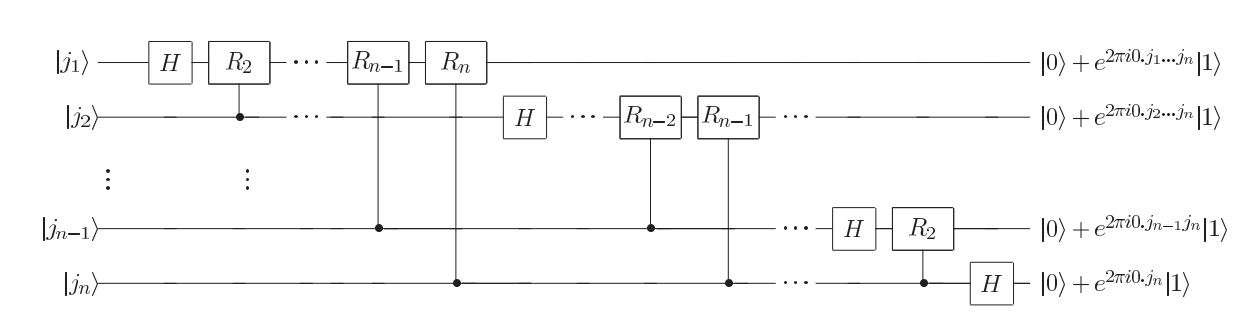

### Forma tensorial

La QFT también puede escribirse como una descomposición en productos tensoriales. Para un estado $|x_1 x_2 \dots x_n\rangle$, se obtiene:

$$
|x_1 x_2 \dots x_n\rangle \rightarrow \frac{1}{2^{n/2}} (|0\rangle + e^{2\pi i 0.x_n} |1\rangle) \otimes (|0\rangle + e^{2\pi i 0.x_{n-1}x_n} |1\rangle) \otimes \cdots
$$

donde $0.x_n$, $0.x_{n-1}x_n$, etc., representan fracciones binarias.


Este algoritmo de uno de los algoritmos mas importantes de la computación cuántica. Este algoritmo es el eje y la clave detras del algoritmo de shor y la estimación de fase cuántica. Para visualizarlo, vamos a representar el circuito del sistema:

In [2]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [3]:
def qft_circuit(n):  #Transformada de Fourier Cuántica para n qubits
    qc = QuantumCircuit(n) #Inicializamos el circuito con n qubits

    for j in range(n): # Aplicamos la puerta H y las puertas de control de fase qubit por qubit
        qc.barrier() # Agrega una barrera para separar visualmente las etapas
        qc.h(j)
        for k in range(j+1, n):
            qc.cp(np.pi / 2**(k-j), k, j) # Puerta de control de fase con ángulo decreciente

    # SWAPs finales
    for i in range(n // 2): # Intercambiamos los qubits para revertir el orden
        qc.swap(i, n - i - 1)

    return qc

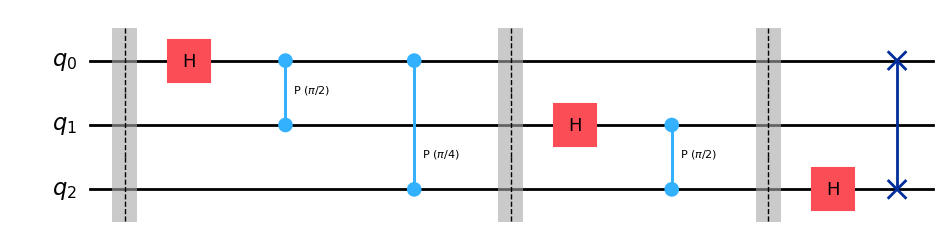

In [4]:
n = 3

qft = qft_circuit(n)

qft.draw('mpl')

Pregunta: ¿Es la QFT la inversa de si misma? ¿Si, no, por que?

## Algoritmo de Quantum Phase Estimation

Ahora si, se viene lo verdaderamente interesante

El algoritmo de **Quantum Phase Estimation (QPE)** permite estimar la fase $\phi$ asociada a un eigenvalor de un operador unitario $U$.

Sea $|\psi\rangle$ un eigenvector de $U$, tal que

$$
U|\psi\rangle = e^{2\pi i \phi} |\psi\rangle
$$

donde $\phi \in [0,1)$ es la fase que se desea estimar.



### Idea general

El objetivo de QPE es transformar la información contenida en la fase del eigenvalor en una cadena de bits que pueda ser medida y nos codifica esa información claramente

Para ello, el algoritmo utiliza dos registros cuánticos:

- Un registro de conteo de $n$ qubits, inicializado en $|0\rangle^{\otimes n}$, que le llamaremos el primer registro
- Un registro que contiene el eigenvector $|\psi\rangle$, que le llamaremos el segundo registro



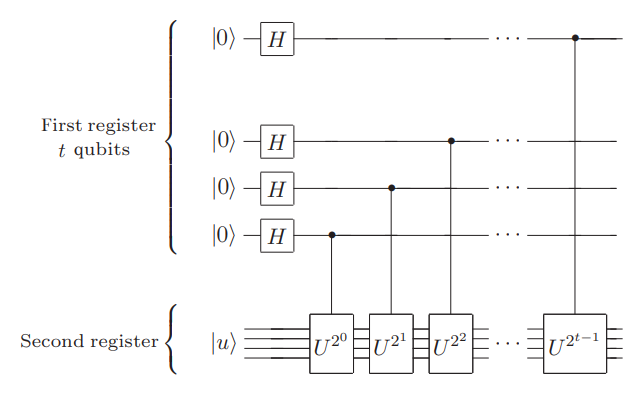

El estado inicial del sistema es:

$$
|0\rangle^{\otimes n} \otimes |\psi\rangle
$$

Tras ello, se aplican compuertas Hadamard a los $t$ qubits del registro de conteo, obteniendo:

$$
\left( \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n-1} |k\rangle \right) \otimes |\psi\rangle
$$

Esto prepara una superposición uniforme de todos los estados computacionales del registro de conteo.

Se aplican compuertas controladas correspondientes a potencias del operador $U$.

En lugar de analizar directamente cada operación, se puede demostrar que el efecto conjunto de estas compuertas controladas es:

$$
|j\rangle |\psi\rangle \rightarrow |j\rangle U^j |\psi\rangle
$$

Ejercicio: Demostrar que las compuertas controladas de la Quantum Phase estimation aplican $|j\rangle |\psi\rangle \rightarrow |j\rangle U^j |\psi\rangle$


Usando este resultado, el estado del sistema evoluciona a:

$$
\frac{1}{\sqrt{2^t}} \sum_{j=0}^{2^t-1} |j\rangle U^j |\psi\rangle
$$

Dado que $|\psi\rangle$ es un eigenvector de $U$, se cumple que

$$
U^j |\psi\rangle = e^{2\pi i j \phi} |\psi\rangle
$$

Por lo tanto, el estado se convierte en:

$$
\frac{1}{\sqrt{2^t}} \sum_{j=0}^{2^t-1} e^{2\pi i j \phi} |j\rangle \otimes |\psi\rangle
$$

La fase $\phi$ queda entonces codificada en las fases relativas del registro de conteo.

Para extraer la información de la fase, se aplica la transformada cuántica de Fourier inversa ($QFT^\dagger$) al registro de conteo.

Si la fase puede escribirse exactamente con $t$ bits binarios, es decir,

$$
\phi = 0.\phi_1 \phi_2 \dots \phi_t
$$

entonces la $QFT^\dagger$ transforma el estado en

$$
|\phi_1 \phi_2 \dots \phi_t\rangle
$$

De esta manera, al medir el registro de conteo se obtiene directamente la representación binaria de $\phi$.

In [5]:
def inverse_qft_circuit(n):
    qc = QuantumCircuit(n, name="QFT†")

    for i in range(n // 2):
        qc.swap(i, n - i - 1)

    for j in reversed(range(n)):
        for k in reversed(range(j+1, n)):
            qc.cp(-np.pi / 2**(k-j), k, j)
        qc.h(j)

    return qc

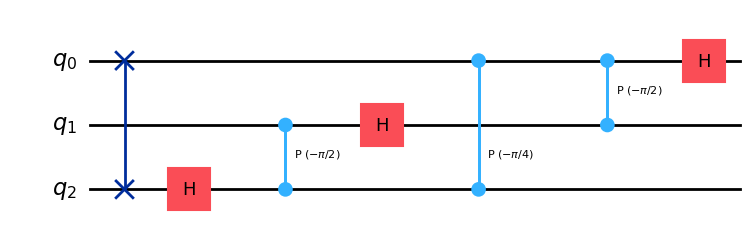

In [6]:
n=3
iqft = inverse_qft_circuit(n)
iqft.draw('mpl')

In [7]:
t = 3  # número de qubits de conteo

iqft_gate = inverse_qft_circuit(t).to_gate()
iqft_gate.label = "IQFT"  #Lo convertimos en una compuerta enorme para visualizarlo de primera mano

## Operador utilizado, eigenvector y por qué funciona QPE

En esta implementación del algoritmo de Quantum Phase Estimation (QPE), se utiliza como operador unitario una compuerta de rotación de fase.

El operador aplicado es:

$$
U = R_z(2\pi \theta)
$$

cuya representación matricial es:

$$
U =
\begin{pmatrix}
1 & 0 \\
0 & e^{2\pi i \theta}
\end{pmatrix}
$$


### Eigenvector y eigenvalor

Observamos que el estado $|1\rangle$ es un eigenvector de $U$, ya que:

$$
U |1\rangle = e^{2\pi i \theta} |1\rangle
$$

Por lo tanto:

- El eigenvector es: $|1\rangle$
- El eigenvalor es: $e^{2\pi i \theta}$

Esto cumple exactamente la condición requerida por el algoritmo de QPE.



Vamos a fabricarnos nuestra propia compuerta a operar, por dinamismo y claridad y aplicamos QPE sobre dicha compuerta

In [8]:
theta = 0.125

In [9]:
qc = QuantumCircuit(t + 1, t) 

target = t

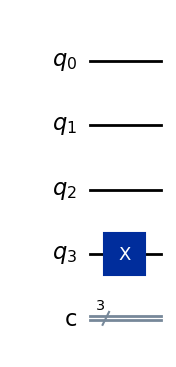

In [10]:
qc.x(target)
qc.draw("mpl")

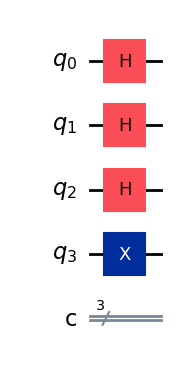

In [11]:
for qubit in range(t):
    qc.h(qubit)

qc.draw("mpl")

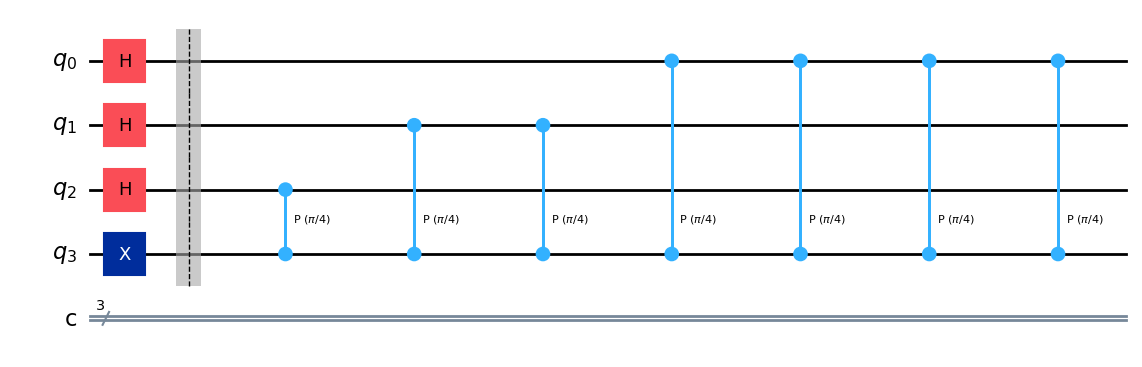

In [12]:
qc.barrier()

for qubit in reversed(range(t)):
    power = 2**(t - qubit - 1)
    for _ in range(power):
        qc.cp(2 * np.pi * theta, qubit, target)

qc.draw("mpl", fold=-1)

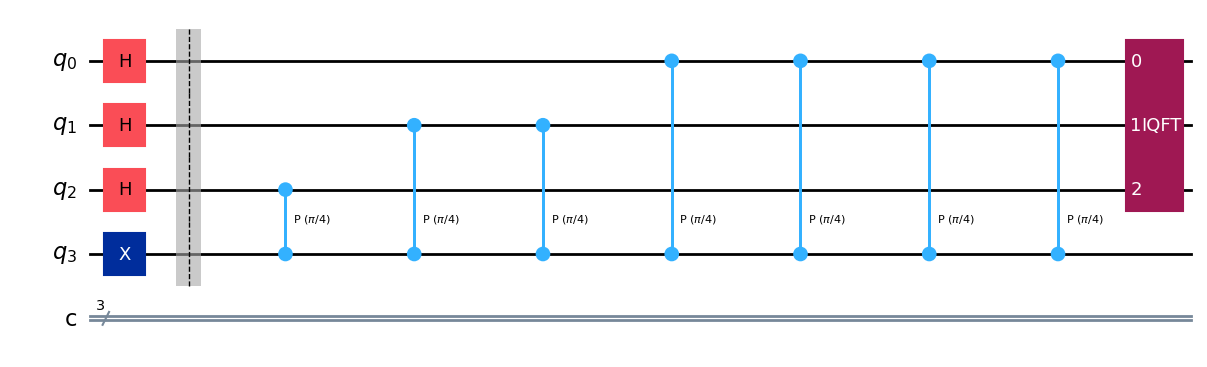

In [13]:
qc.append(iqft_gate, range(t))
qc.draw("mpl", fold=-1)

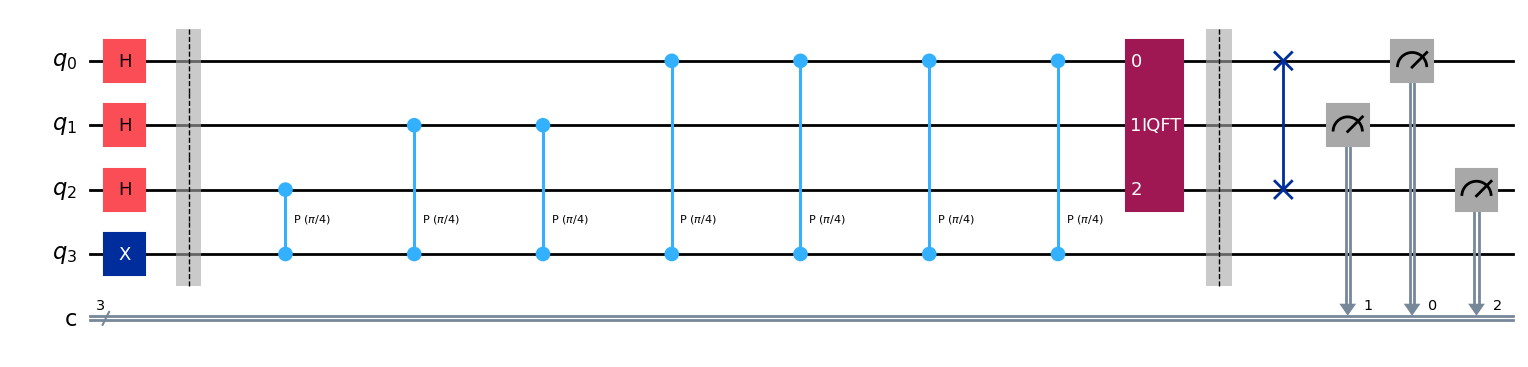

In [14]:
qc.barrier()
for i in range(t // 2):
    qc.swap(i, t - i - 1) # Intercambiamos los qubits para revertir el orden por que qiskit lo hace al revés
qc.measure(range(t), range(t))
qc.draw("mpl", fold=-1)

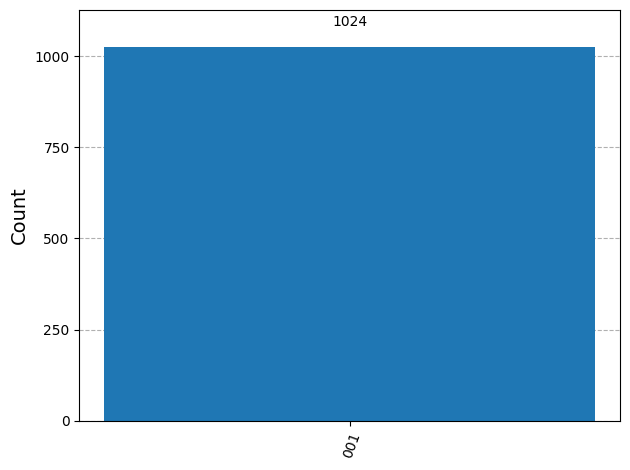

In [15]:
sim = AerSimulator(method='statevector')

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()
plot_histogram(counts)

Si recuperamos 001, es porque $\phi=0.001$ en binario. Y $0.001$ en binario? es $0*0.5+0*0.25+0*1.125=0.125$